In [1]:
import numpy as np # linear algebra
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(0)
#from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
#from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_regression

In [2]:
rain_file_path = '../data/train.csv'
rain_data = pd.read_csv(rain_file_path)
test_file_path = "../data/test.csv"
test_data = pd.read_csv(test_file_path)
test_data_full = pd.read_csv(test_file_path)

In [3]:
rain_data.shape


(2190, 13)

scikit-learn >=0.23.0,<1.2

In [4]:
rain_data.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [5]:
rain_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             2190 non-null   int64  
 1   day            2190 non-null   int64  
 2   pressure       2190 non-null   float64
 3   maxtemp        2190 non-null   float64
 4   temparature    2190 non-null   float64
 5   mintemp        2190 non-null   float64
 6   dewpoint       2190 non-null   float64
 7   humidity       2190 non-null   float64
 8   cloud          2190 non-null   float64
 9   sunshine       2190 non-null   float64
 10  winddirection  2190 non-null   float64
 11  windspeed      2190 non-null   float64
 12  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(3)
memory usage: 222.6 KB


In [6]:
rain_data.isnull().sum()

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
rainfall         0
dtype: int64

In [7]:
test_data.isnull().sum()

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    1
windspeed        0
dtype: int64

In [8]:
test_data.loc[test_data.winddirection.isnull()]

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
517,2707,153,1007.8,32.9,30.6,28.9,22.0,65.0,75.0,8.2,NaN,17.2


In [9]:
test_data["winddirection"][510:525]

510    220.0
511    100.0
512    220.0
513    230.0
514     10.0
515    230.0
516    100.0
517      NaN
518    220.0
519    220.0
520     50.0
521    220.0
522    220.0
523    220.0
524    230.0
Name: winddirection, dtype: float64

In [10]:
test_data.fillna(value=160, inplace=True)

In [11]:
test_data["winddirection"][510:525]

510    220.0
511    100.0
512    220.0
513    230.0
514     10.0
515    230.0
516    100.0
517    160.0
518    220.0
519    220.0
520     50.0
521    220.0
522    220.0
523    220.0
524    230.0
Name: winddirection, dtype: float64

In [12]:
rain_data.describe()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,1094.500000,179.948402,1013.602146,26.365799,23.953059,22.170091,20.454566,82.036530,75.721918,3.744429,104.863151,21.804703,0.753425
std,632.342866,105.203592,5.655366,5.654330,5.222410,5.059120,5.288406,7.800654,18.026498,3.626327,80.002416,9.898659,0.431116
min,0.000000,1.000000,999.000000,10.400000,7.400000,4.000000,-0.300000,39.000000,2.000000,0.000000,10.000000,4.400000,0.000000
25%,547.250000,89.000000,1008.600000,21.300000,19.300000,17.700000,16.800000,77.000000,69.000000,0.400000,40.000000,14.125000,1.000000
50%,1094.500000,178.500000,1013.000000,27.800000,25.500000,23.850000,22.150000,82.000000,83.000000,2.400000,70.000000,20.500000,1.000000
75%,1641.750000,270.000000,1017.775000,31.200000,28.400000,26.400000,25.000000,88.000000,88.000000,6.800000,200.000000,27.900000,1.000000
max,2189.000000,365.000000,1034.600000,36.000000,31.500000,29.800000,26.700000,98.000000,100.000000,12.100000,300.000000,59.500000,1.000000


In [13]:
rain_data.drop(['id', 'day'], axis=1, inplace=True)
test_data.drop(['id', 'day'], axis=1, inplace=True)

In [14]:
test_data.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3
1,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3
2,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9
3,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6
4,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4


In [15]:
rain_data.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [16]:
X = rain_data.drop(labels="rainfall", axis=1)
y = rain_data['rainfall']
X_test = test_data

In [17]:
rf_model = RandomForestRegressor(random_state = 1)

# fit your model
rf_model.fit(X, y)
score = cross_val_score(rf_model, X, y, cv=5, scoring="roc_auc")
print(score)
score.mean()

[0.85746822 0.8964572  0.91166476 0.85620869 0.86978512]


0.8783167997454522

In [17]:
#cols = X.columns požito v 1.verzy
cols = ["temparature", "maxtemp", "mintemp"]
cols_for_scaling = X.loc[:, ["temparature", "maxtemp", "mintemp"]]
cols_for_scaling

,temparature,maxtemp,mintemp
0,20.6,21.2,19.9
1,16.9,16.2,15.8
2,16.1,19.4,14.6
3,17.8,18.1,16.9
4,18.4,21.3,15.2
...,...,...,...
2185,20.6,23.2,19.1
2186,17.3,17.2,16.3
2187,16.3,19.0,14.3
2188,15.2,16.4,13.8


In [18]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

scaled_X = ms.fit_transform(cols_for_scaling)
print(scaled_X)
scaled_X = pd.DataFrame(scaled_X, columns=[cols])
print(scaled_X)

[[0.54771784 0.421875   0.61627907]
 [0.39419087 0.2265625  0.45736434]
 [0.36099585 0.3515625  0.41085271]
 ...
 [0.36929461 0.3359375  0.39922481]
 [0.32365145 0.234375   0.37984496]
 [0.48547718 0.421875   0.54263566]]
     temparature   maxtemp   mintemp
0       0.547718  0.421875  0.616279
1       0.394191  0.226562  0.457364
2       0.360996  0.351562  0.410853
3       0.431535  0.300781  0.500000
4       0.456432  0.425781  0.434109
...          ...       ...       ...
2185    0.547718  0.500000  0.585271
2186    0.410788  0.265625  0.476744
2187    0.369295  0.335938  0.399225
2188    0.323651  0.234375  0.379845
2189    0.485477  0.421875  0.542636

[2190 rows x 3 columns]


In [19]:
cols_for_scaling_test = X_test.loc[:, ["temparature", "maxtemp", "mintemp"]]
scaled_X_test = ms.fit_transform(cols_for_scaling_test)
scaled_X_test = pd.DataFrame(scaled_X_test, columns=[cols])

In [20]:
cols_for_scaling_test

,temparature,maxtemp,mintemp
0,15.8,17.5,12.7
1,16.5,17.5,15.8
2,10.4,11.2,9.4
3,17.3,20.6,15.2
4,13.8,16.1,6.4
...,...,...,...
725,17.6,18.2,16.1
726,18.1,23.2,16.0
727,18.5,21.0,17.0
728,20.0,21.0,19.7


In [21]:
scaled_X_test.head()

,temparature,maxtemp,mintemp
0,0.382239,0.355634,0.341365
1,0.409266,0.355634,0.465863
2,0.173745,0.133803,0.208835
3,0.440154,0.464789,0.441767
4,0.305019,0.306338,0.088353


In [22]:
scaled_X.head()

,temparature,maxtemp,mintemp
0,0.547718,0.421875,0.616279
1,0.394191,0.226562,0.457364
2,0.360996,0.351562,0.410853
3,0.431535,0.300781,0.500000
4,0.456432,0.425781,0.434109


In [23]:
kmeans = KMeans(n_clusters=2, random_state=0) 

kmeans.fit(scaled_X)

KMeans(n_clusters=2, random_state=0)

In [24]:
kmeans.inertia_

66.37242635124252

In [25]:
kmeans.cluster_centers_

array([[0.83605855, 0.77362637, 0.83842746],
       [0.43997485, 0.37554451, 0.48229269]])

In [26]:
labels = kmeans.labels_

# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)

print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))

Result: 969 out of 2190 samples were correctly labeled.


In [27]:
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Accuracy score: 0.44


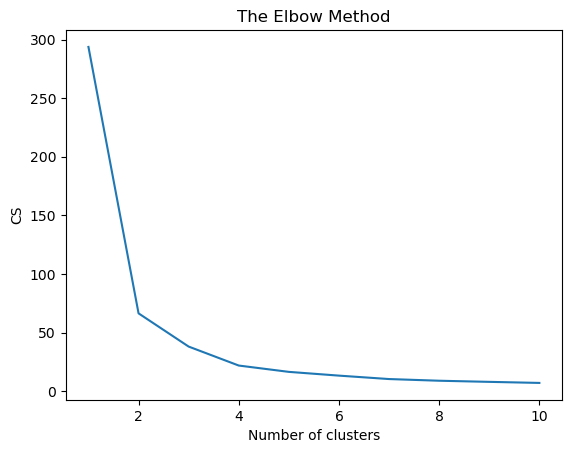

In [28]:
from sklearn.cluster import KMeans
cs = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(scaled_X)
    cs.append(kmeans.inertia_)
plt.plot(range(1, 11), cs)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('CS')
plt.show()

In [29]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, n_init=10, random_state=0)

kmeans.fit(scaled_X)

labels = kmeans.labels_

# check how many of the samples were correctly labeled

correct_labels = sum(y == labels)

print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))

print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 969 out of 2190 samples were correctly labeled.
Accuracy score: 0.44


In [30]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3,n_init=10,random_state=0)

kmeans.fit(scaled_X)

labels = kmeans.labels_

# check how many of the samples were correctly labeled

correct_labels = sum(y == labels)

print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))

print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 770 out of 2190 samples were correctly labeled.
Accuracy score: 0.35


In [31]:
kmeans = KMeans(n_clusters=4,n_init=10, random_state=0)

kmeans.fit(scaled_X)

# check how many of the samples were correctly labeled
labels = kmeans.labels_

correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 518 out of 2190 samples were correctly labeled.
Accuracy score: 0.24


In [32]:
kmeans = KMeans(n_clusters=5,n_init=10, random_state=0)

kmeans.fit(scaled_X)

# check how many of the samples were correctly labeled
labels = kmeans.labels_

correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 378 out of 2190 samples were correctly labeled.
Accuracy score: 0.17


In [33]:
kmeans = KMeans(n_clusters=2, random_state=0)
X["Cluster"] = kmeans.fit_predict(scaled_X)
#X_test["Cluster"] = kmeans.fit_predict(scaled_X_test)

In [34]:
kmeans = KMeans(n_clusters=2, random_state=0) 

kmeans.fit(scaled_X_test)

KMeans(n_clusters=2, random_state=0)

In [35]:
kmeans.inertia_

21.217455719416982

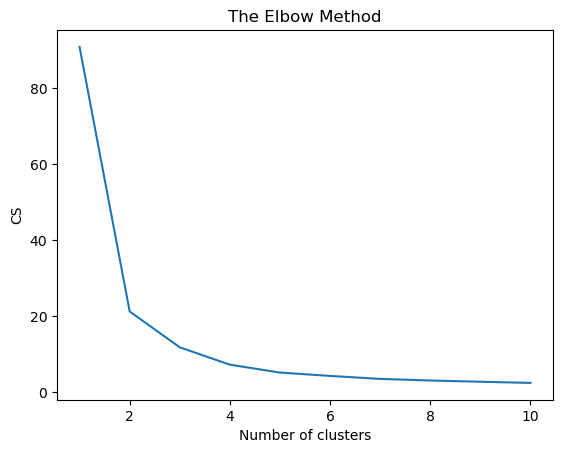

In [36]:
cs = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(scaled_X_test)
    cs.append(kmeans.inertia_)
plt.plot(range(1, 11), cs)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('CS')
plt.show()

In [37]:
kmeans = KMeans(n_clusters=2,n_init=10,random_state=0)

kmeans.fit(scaled_X_test)

labels = kmeans.labels_

In [38]:
kmeans = KMeans(n_clusters=2, random_state=0)
X_test["Cluster"] = kmeans.fit_predict(scaled_X_test)

In [39]:
X_test

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Cluster
0,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3,0
1,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3,0
2,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9,0
3,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6,0
4,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4,0
...,...,...,...,...,...,...,...,...,...,...,...
725,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,34.3,0
726,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,25.2,0
727,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,21.9,0
728,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,39.5,0


In [40]:
X

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Cluster
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,1
...,...,...,...,...,...,...,...,...,...,...,...
2185,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1
2186,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1
2187,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1
2188,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1


In [41]:
features = X.columns

In [42]:
features

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'sunshine', 'winddirection', 'windspeed', 'Cluster'],
      dtype='object')

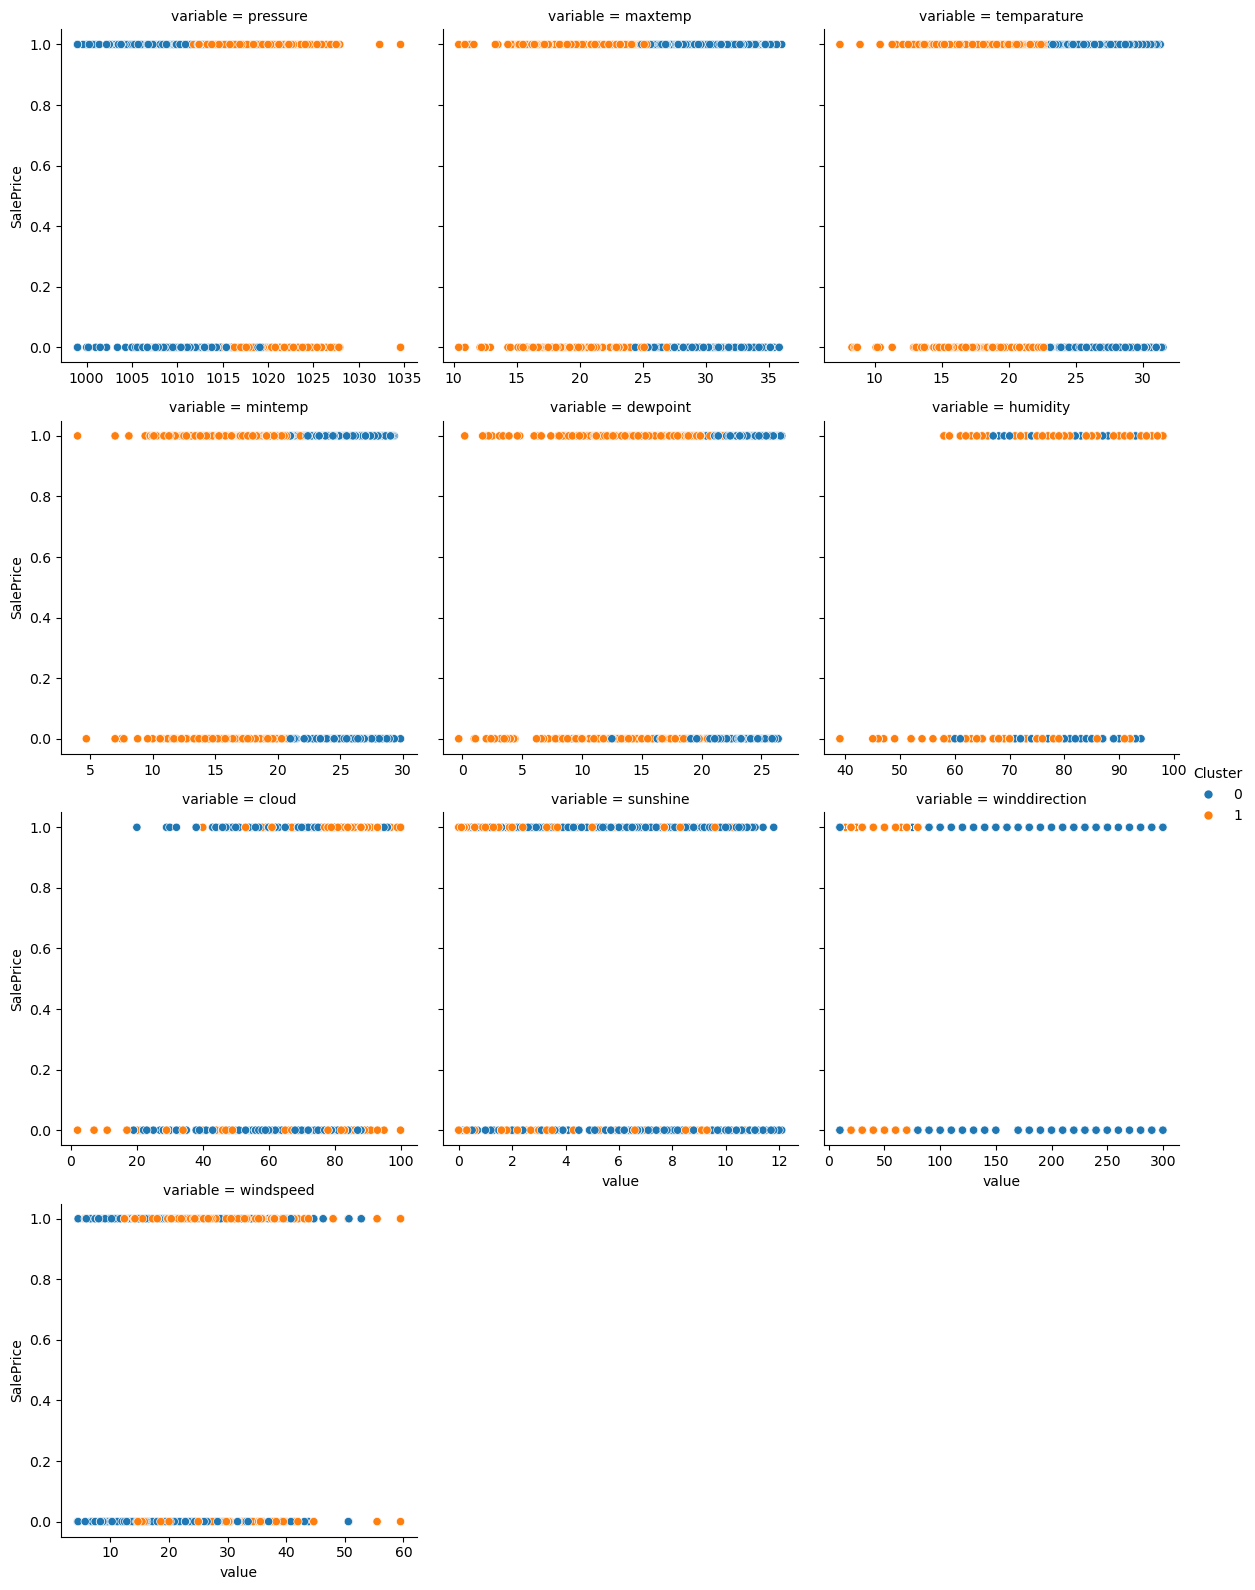

In [43]:
Xy = X.copy()
Xy["Cluster"] = Xy.Cluster.astype("category")
Xy["SalePrice"] = y
sns.relplot(
    x="value", y="SalePrice", hue="Cluster", col="variable",
    height=4, aspect=1, facet_kws={'sharex': False}, col_wrap=3,
    data=Xy.melt(
        value_vars=features, id_vars=["SalePrice", "Cluster"],
    ),
);


In [44]:
X_test

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Cluster
0,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3,0
1,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3,0
2,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9,0
3,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6,0
4,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4,0
...,...,...,...,...,...,...,...,...,...,...,...
725,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,34.3,0
726,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,25.2,0
727,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,21.9,0
728,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,39.5,0


In [45]:
# YOUR CODE HERE: Create the cluster-distance features using `fit_transform`
X_cd = kmeans.fit_transform(scaled_X)
X_cd_test = kmeans.fit_transform(scaled_X_test)


# Label features and join to dataset
X_cd = pd.DataFrame(X_cd, columns=[f"Centroid_{i}" for i in range(X_cd.shape[1])])
X_cd_test = pd.DataFrame(X_cd_test, columns=[f"Centroid_{i}" for i in range(X_cd_test.shape[1])])
X = X.join(X_cd)
X_test = X_test.join(X_cd_test)

In [46]:
X_test

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Cluster,Centroid_0,Centroid_1
0,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3,0,0.190479,0.823115
1,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3,0,0.109136,0.734663
2,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9,0,0.510231,1.146228
3,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6,0,0.055154,0.669401
4,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4,0,0.451545,1.061764
...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,34.3,0,0.067913,0.688722
726,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,25.2,0,0.111145,0.587399
727,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,21.9,0,0.047397,0.590508
728,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,39.5,0,0.160255,0.497895


In [47]:
X

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Cluster,Centroid_0,Centroid_1
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1,0.506181,0.178066
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1,0.799834,0.157839
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1,0.765926,0.109163
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1,0.708346,0.077294
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,1,0.654665,0.071528
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1,0.471275,0.194171
2186,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1,0.754808,0.113864
2187,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1,0.776105,0.116037
2188,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1,0.873871,0.209656


In [48]:
cols_scaling = X.columns

In [49]:
X.dtypes

pressure         float64
maxtemp          float64
temparature      float64
mintemp          float64
dewpoint         float64
humidity         float64
cloud            float64
sunshine         float64
winddirection    float64
windspeed        float64
Cluster            int32
Centroid_0       float64
Centroid_1       float64
dtype: object

In [50]:
from mlxtend.preprocessing import minmax_scaling

X_scaled = minmax_scaling(X, columns=cols_scaling)
X_test_scaled = minmax_scaling(X_test, columns=cols_scaling)
X_scaled

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Cluster,Centroid_0,Centroid_1
0,0.516854,0.421875,0.547718,0.616279,0.729630,0.813559,0.877551,0.090909,0.172414,0.232305,1.0,0.378296,0.180317
1,0.575843,0.226562,0.394191,0.457364,0.581481,0.949153,0.908163,0.000000,0.137931,0.317604,1.0,0.600681,0.158579
2,0.705056,0.351562,0.360996,0.410853,0.355556,0.610169,0.459184,0.685950,0.206897,0.248639,1.0,0.575002,0.106264
3,0.404494,0.300781,0.431535,0.500000,0.633333,0.949153,0.948980,0.000000,0.172414,0.566243,1.0,0.531396,0.072013
4,0.640449,0.425781,0.456432,0.434109,0.366667,0.220339,0.438776,0.297521,0.103448,0.370236,1.0,0.490743,0.065817
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,0.438202,0.500000,0.547718,0.585271,0.748148,0.983051,0.877551,0.008264,0.103448,0.321234,1.0,0.351861,0.197626
2186,0.376404,0.265625,0.410788,0.476744,0.577778,0.881356,0.877551,0.000000,0.137931,0.560799,1.0,0.566582,0.111317
2187,0.401685,0.335937,0.369295,0.399225,0.477778,0.677966,0.785714,0.413223,0.103448,0.517241,1.0,0.582710,0.113653
2188,0.654494,0.234375,0.323651,0.379845,0.555556,0.898305,0.928571,0.008264,0.103448,0.246824,1.0,0.656749,0.214268


In [51]:
X_test_scaled

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Cluster,Centroid_0,Centroid_1
0,0.605590,0.355634,0.382239,0.341365,0.558052,0.966102,0.99,0.000000,0.137931,0.360000,0.0,0.192394,0.566383
1,0.512422,0.355634,0.409266,0.465863,0.565543,0.983051,0.99,0.000000,0.137931,0.560000,0.0,0.100272,0.504697
2,0.742236,0.133803,0.173745,0.208835,0.333333,0.796610,0.96,0.000000,0.103448,0.225455,0.0,0.554516,0.791718
3,0.711180,0.464789,0.440154,0.441767,0.355805,0.610169,0.45,0.601695,0.034483,0.838182,0.0,0.039136,0.459184
4,0.689441,0.306338,0.305019,0.088353,0.161049,0.491525,0.49,0.779661,0.034483,0.270909,0.0,0.488053,0.732814
...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,0.645963,0.380282,0.451737,0.477912,0.513109,0.966102,0.95,0.000000,0.034483,0.541818,0.0,0.053586,0.472658
726,0.363354,0.556338,0.471042,0.473896,0.599251,0.661017,0.80,0.135593,0.103448,0.376364,0.0,0.102547,0.401996
727,0.704969,0.478873,0.486486,0.514056,0.580524,0.898305,0.96,0.000000,0.137931,0.316364,0.0,0.030351,0.404164
728,0.447205,0.478873,0.544402,0.622490,0.741573,0.932203,0.93,0.000000,0.137931,0.636364,0.0,0.158165,0.339577


In [52]:
# Define the model. Set random_state to 1
rf_model = RandomForestRegressor(random_state = 1)

# fit your model
rf_model.fit(X_scaled, y)
#rf_preds = rf_model.predict(val_X)
score = cross_val_score(rf_model, X_scaled, y, cv=5, scoring="roc_auc")
print(score)
score.mean()

[0.86340042 0.89951134 0.90872069 0.85540002 0.86934531]


0.8792755559713635

In [53]:
xgb_model = XGBRegressor()
xgb_model.fit(X_scaled, y)
score = cross_val_score(xgb_model, X_scaled, y, cv=5, scoring="roc_auc")
print(score)
score.mean()

[0.80693856 0.85028754 0.86039635 0.84359053 0.83654813]


0.8395522202025768

In [54]:
# Break off validation set from training data
X_train, X_valid, y_train, y_valid = train_test_split(X_scaled, y, 
                                                                train_size=0.8, test_size=0.2,
                                                                random_state=0)

In [55]:
# Define the model. Set random_state to 1
rf_model = RandomForestRegressor(random_state = 1)

# fit your model
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_valid)
score = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring="roc_auc")
print(score)
score.mean()

[0.89078543 0.82447037 0.81908302 0.85090585 0.85019742]


0.847088418904723

In [56]:
rf_model.fit(X_scaled, y)
rf_test_preds = rf_model.predict(X_test)

In [57]:
test_data_full["id"]

0      2190
1      2191
2      2192
3      2193
4      2194
       ... 
725    2915
726    2916
727    2917
728    2918
729    2919
Name: id, Length: 730, dtype: int64

In [58]:
X_test["id"] = test_data_full["id"]


In [59]:
X_test["rainfall"] = rf_test_preds

In [60]:
X_test

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Cluster,Centroid_0,Centroid_1,id,rainfall
0,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3,0,0.190479,0.823115,2190,0.68
1,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3,0,0.109136,0.734663,2191,0.66
2,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9,0,0.510231,1.146228,2192,0.64
3,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6,0,0.055154,0.669401,2193,0.52
4,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4,0,0.451545,1.061764,2194,0.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,34.3,0,0.067913,0.688722,2915,0.66
726,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,25.2,0,0.111145,0.587399,2916,0.55
727,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,21.9,0,0.047397,0.590508,2917,0.66
728,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,39.5,0,0.160255,0.497895,2918,0.66


In [61]:
X_test.to_csv('submission.csv', columns=['id','rainfall'], index=False)

In [62]:
# Utility functions from Tutorial
def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

In [63]:
mi_scores = make_mi_scores(X_scaled, y)

cloud            0.200412
sunshine         0.153224
humidity         0.146553
maxtemp          0.042379
temparature      0.020995
Centroid_1       0.016801
Centroid_0       0.010907
mintemp          0.008686
pressure         0.006676
dewpoint         0.005802
winddirection    0.000000
windspeed        0.000000
Cluster          0.000000
Name: MI Scores, dtype: float64


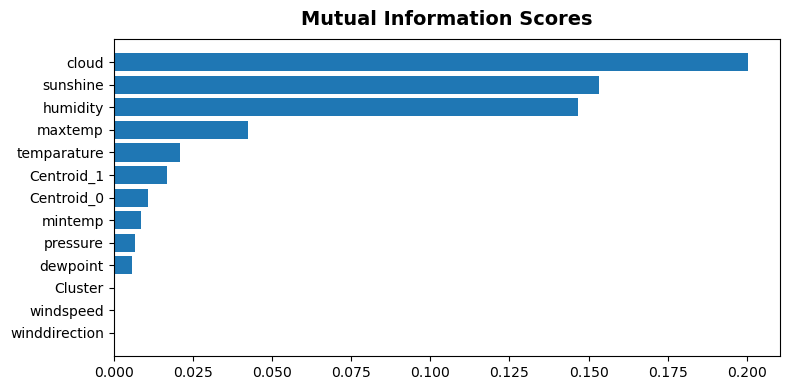

In [81]:
print(mi_scores.head(20))
# print(mi_scores.tail(20))  # uncomment to see bottom 20

plt.figure(dpi=100, figsize=(8, 4))
plot_mi_scores(mi_scores.head(50))
# plot_mi_scores(mi_scores.tail(20))  # uncomment to see bottom 20

In [83]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [71]:
features = [
    "cloud",
    "sunshine",
    "humidity",
    "maxtemp",
    "temparature",
    "Centroid_0",
    "mintemp",
    "pressure",
    "dewpoint",
    "winddirection",
    "windspeed",
    "Cluster"
    
]

print("Correlation with SalePrice:\n")
print(X_scaled[features].corrwith(y))

Correlation with SalePrice:

cloud            0.641191
sunshine        -0.555287
humidity         0.454213
maxtemp         -0.079304
temparature     -0.049660
Centroid_0      -0.012067
mintemp         -0.026841
pressure        -0.049886
dewpoint         0.081965
winddirection   -0.006939
windspeed        0.111625
Cluster          0.012974
dtype: float64


In [85]:
from sklearn.decomposition import PCA

# Set Matplotlib defaults
plt.style.use("seaborn-v0_8-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)


def apply_pca(X, standardize=True):
    # Standardize
    if standardize:
        X = (X - X.mean(axis=0)) / X.std(axis=0)
    # Create principal components
    pca = PCA()
    X_pca = pca.fit_transform(X)
    # Convert to dataframe
    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)
    # Create loadings
    loadings = pd.DataFrame(
        pca.components_.T,  # transpose the matrix of loadings
        columns=component_names,  # so the columns are the principal components
        index=X.columns,  # and the rows are the original features
    )
    return pca, X_pca, loadings


def plot_variance(pca, width=8, dpi=100):
    # Create figure
    fig, axs = plt.subplots(1, 2)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    # Explained variance
    evr = pca.explained_variance_ratio_
    axs[0].bar(grid, evr)
    axs[0].set(
        xlabel="Component", title="% Explained Variance", ylim=(0.0, 1.0)
    )
    # Cumulative Variance
    cv = np.cumsum(evr)
    axs[1].plot(np.r_[0, grid], np.r_[0, cv], "o-")
    axs[1].set(
        xlabel="Component", title="% Cumulative Variance", ylim=(0.0, 1.0)
    )
    # Set up figure
    fig.set(figwidth=8, dpi=100)
    return axs


def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


def score_dataset(X, y, model=XGBRegressor()):
    # Label encoding for categoricals
    for colname in X.select_dtypes(["category", "object"]):
        X[colname], _ = X[colname].factorize()
    # Metric for Housing competition is RMSLE (Root Mean Squared Log Error)
    score = cross_val_score(
        model, X, y, cv=5, scoring="neg_mean_squared_log_error",
    )
    score = -1 * score.mean()
    score = np.sqrt(score)
    return score